In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report, roc_curve,auc,roc_auc_score
import joblib 
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
df=pd.read_csv(r"C:\Users\USER\Downloads\archive (3)\fetal_health.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


In [5]:
#checking null values by %
print(df.isna().sum()*100)

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

baseline value                                             0.020312
accelerations                                              1.204392
fetal_movement                                             7.811477
uterine_contractions                                       0.159315
light_decelerations                                        1.718437
severe_decelerations                                      17.353457
prolongued_decelerations                                   4.323965
abnormal_short_term_variability                           -0.011829
mean_value_of_short_term_variability                       1.657339
percentage_of_time_with_abnormal_long_term_variability     2.195075
mean_value_of_long_term_variability                        1.331998
histogram_width                                            0.314235
histogram_min                                              0.115784
histogram_max                                              0.577862
histogram_number_of_peaks                       

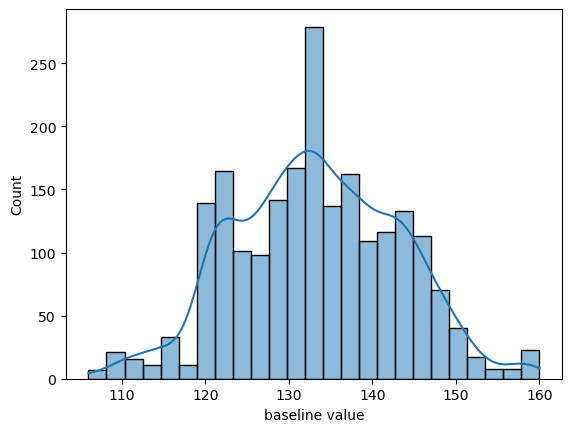

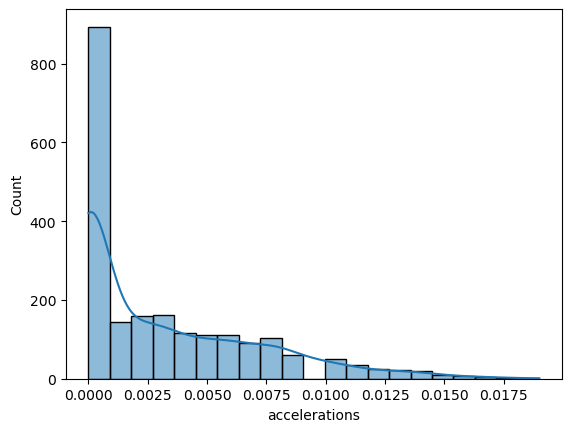

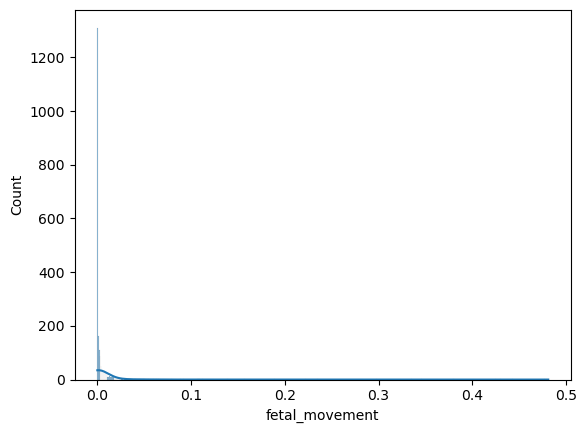

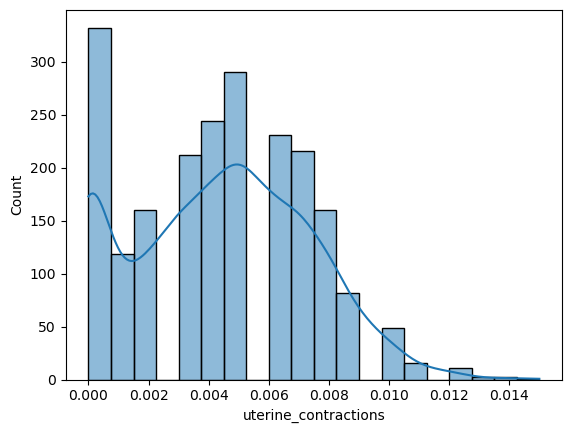

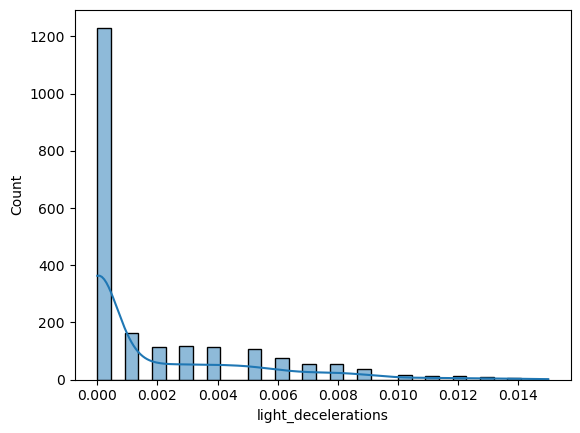

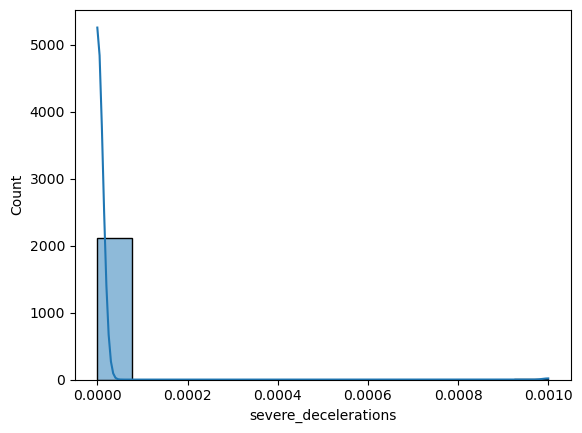

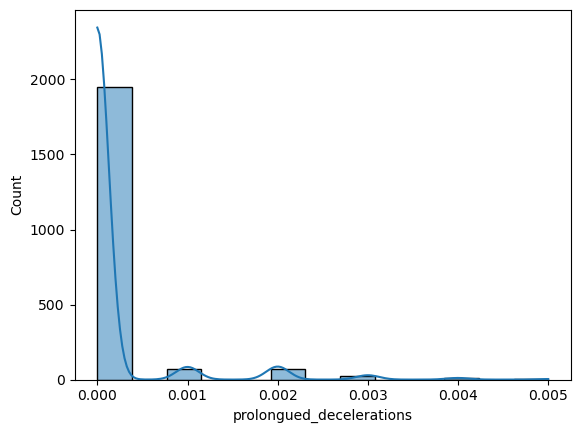

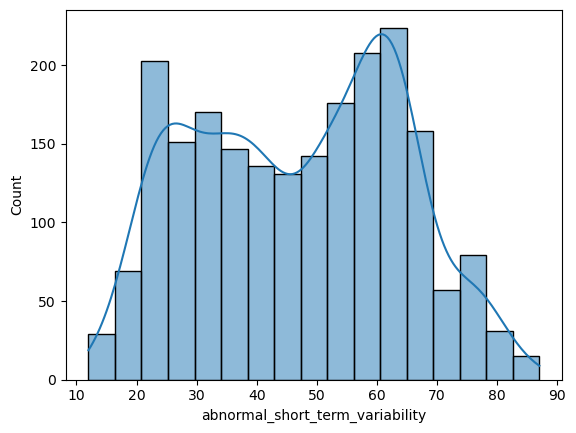

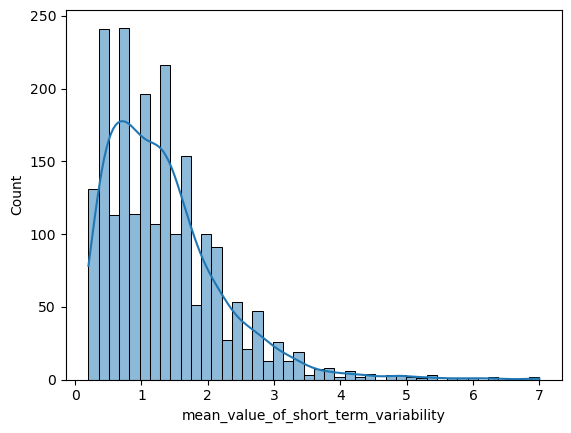

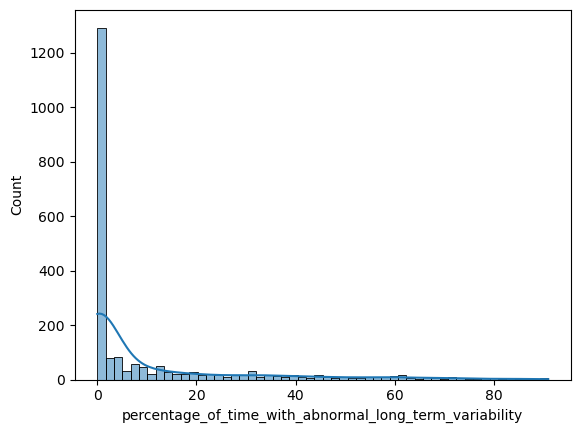

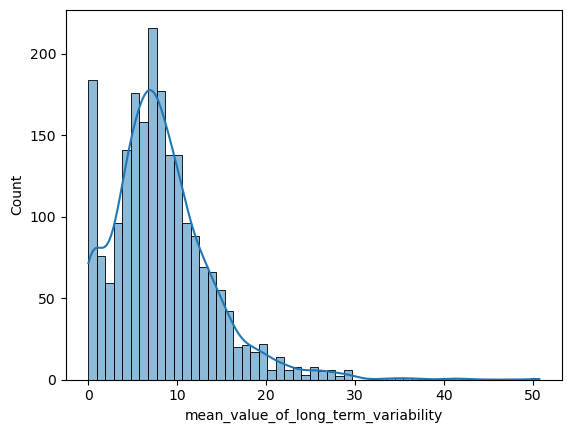

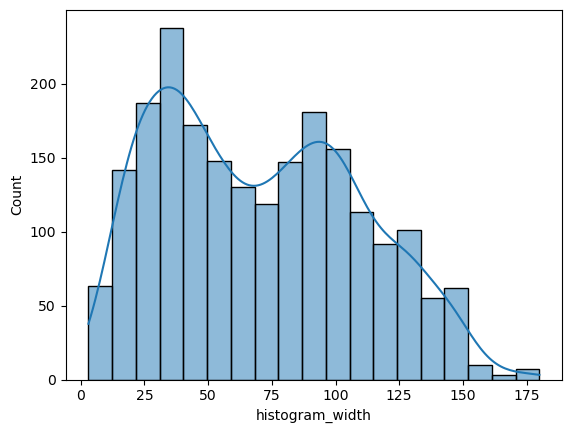

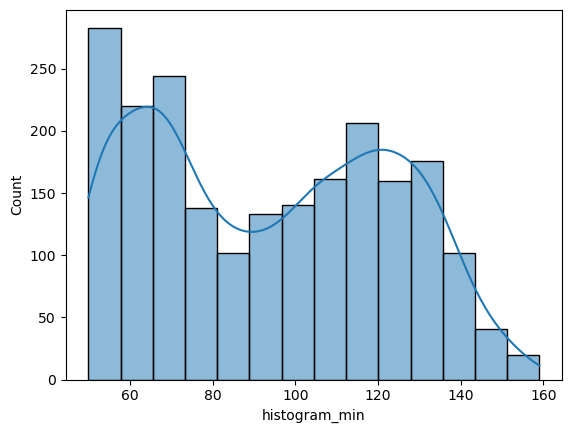

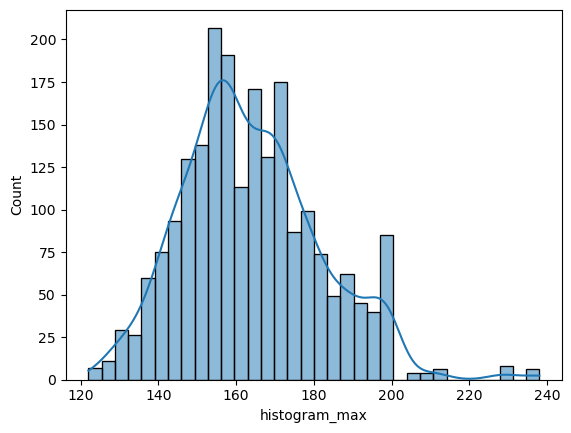

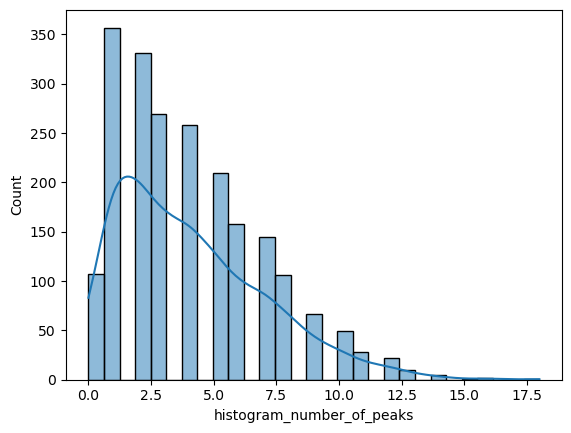

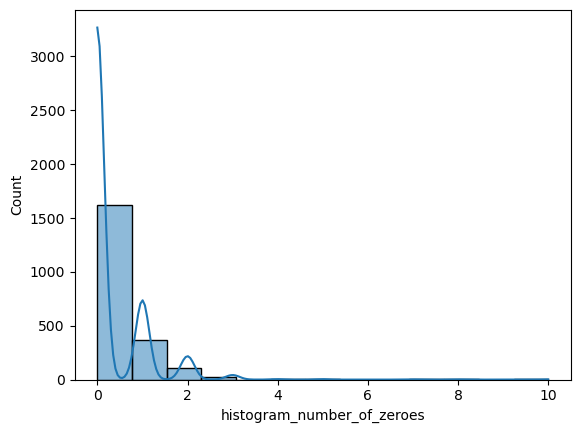

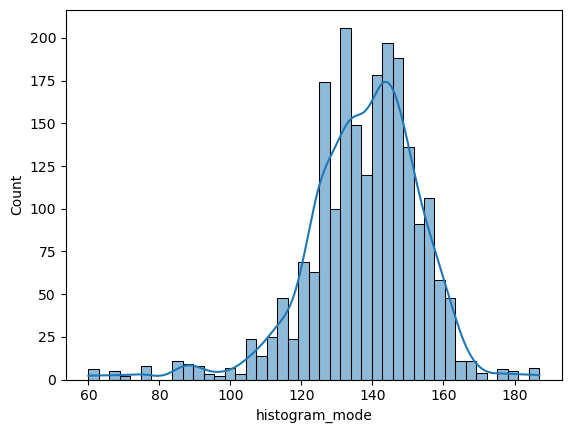

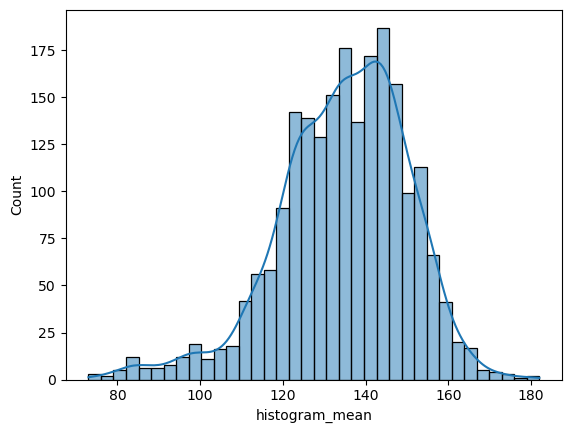

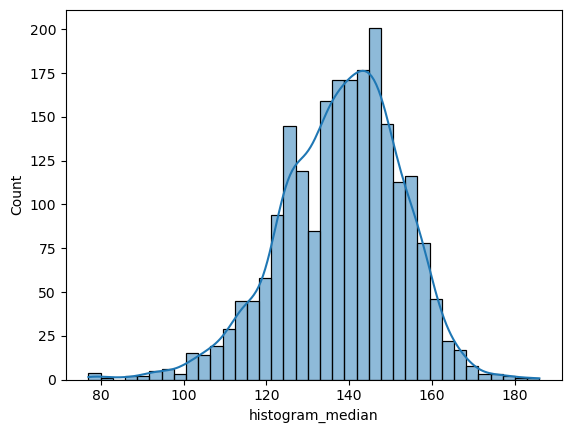

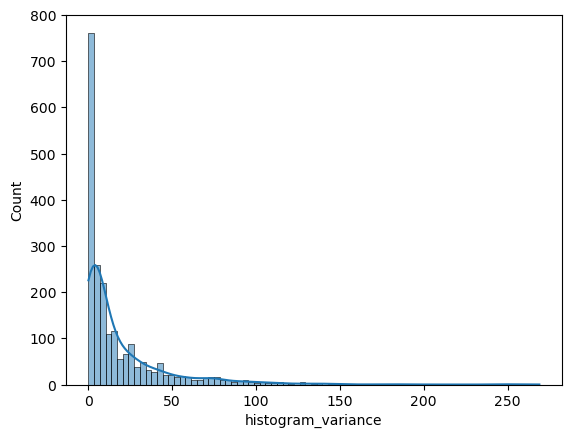

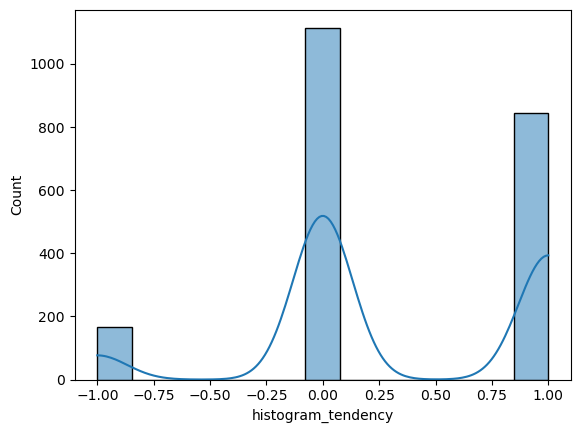

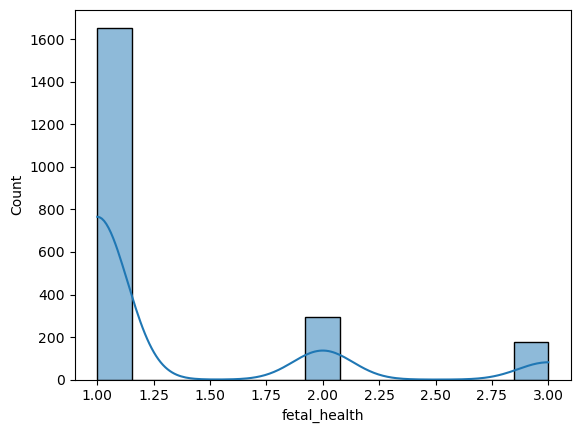

In [6]:
#Data Distrubution monitering skewness
print(df.skew())
for i in df.columns: 
    sns.histplot(data=df,x=i,kde=True)
    plt.show()

In [7]:
x = df.drop("fetal_health", axis=1)
y = df["fetal_health"] - 1

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

weights = compute_sample_weight('balanced', y_train)

pipe = Pipeline([
    
    ('model', XGBClassifier( n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9
))
])

pipe.fit(x_train, y_train, model__sample_weight=weights)

pred = pipe.predict(x_test)



# Accuracy
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, pred))

Accuracy: 0.9553990610328639
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       333
         1.0       0.84      0.91      0.87        64
         2.0       0.91      1.00      0.95        29

    accuracy                           0.96       426
   macro avg       0.91      0.96      0.93       426
weighted avg       0.96      0.96      0.96       426



In [8]:
weights = compute_sample_weight('balanced', y_train)

pipe.fit(x_train, y_train, model__sample_weight=weights)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [9]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, pred))

[[320  11   2]
 [  5  58   1]
 [  0   0  29]]


In [10]:
y_prob = pipe.predict_proba(x_test)
print(y_prob)

[[9.8315066e-01 1.5514804e-02 1.3345336e-03]
 [9.9108374e-01 1.8185469e-03 7.0977644e-03]
 [9.8383957e-01 1.0544971e-02 5.6154574e-03]
 ...
 [9.9864656e-01 1.0867226e-03 2.6672229e-04]
 [9.8794889e-01 7.4680266e-03 4.5830896e-03]
 [2.1130253e-01 7.8347939e-01 5.2180775e-03]]


In [11]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

In [12]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.988807667013238


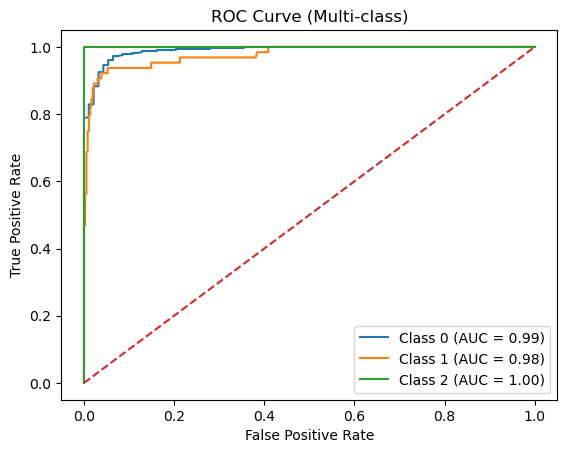

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

n_classes = 3

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

In [14]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


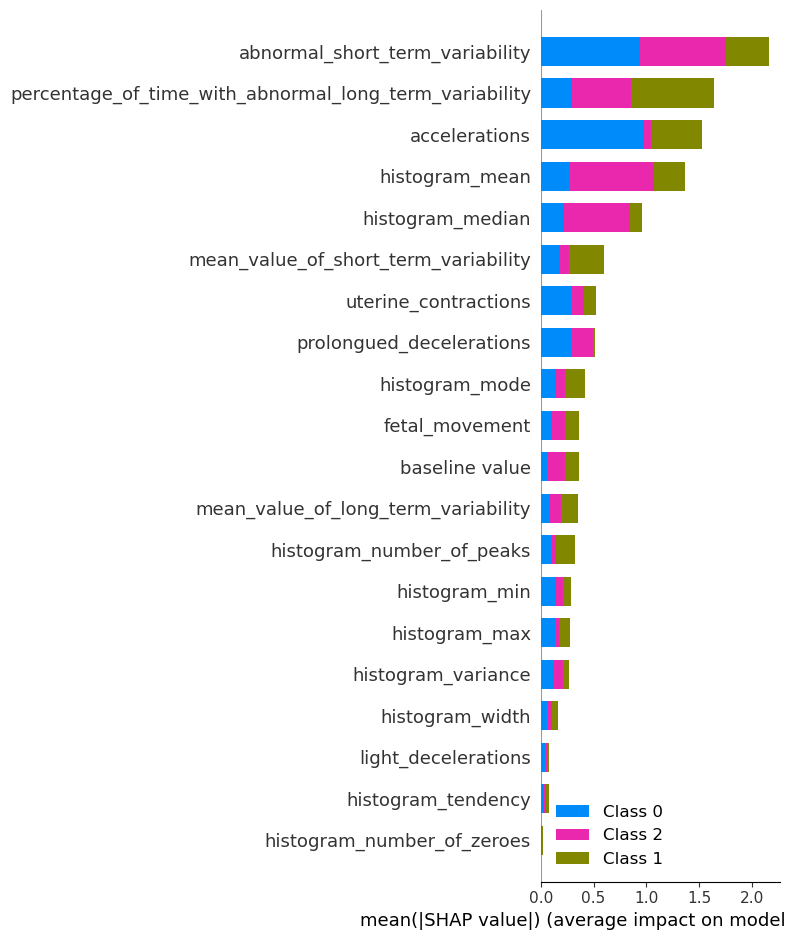

In [15]:
import shap

# get model from pipeline
model = pipe.named_steps['model']

explainer = shap.Explainer(model)
shap_values = explainer(x_test)

# summary plot
shap.summary_plot(shap_values, x_test)

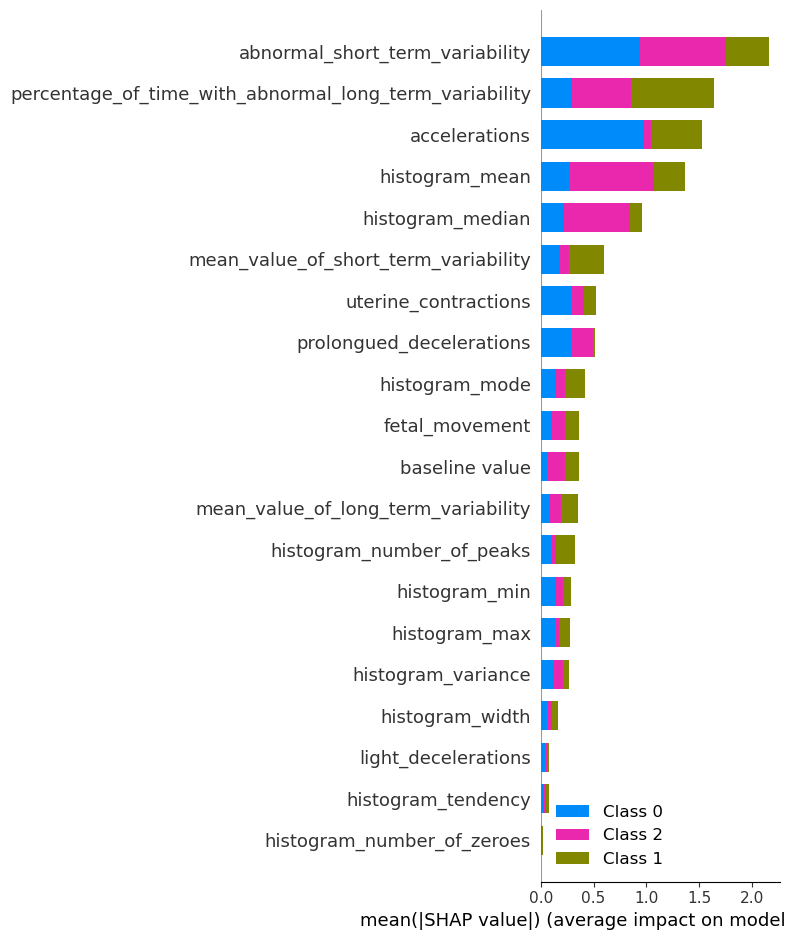

In [17]:
shap.summary_plot(shap_values, x_test)

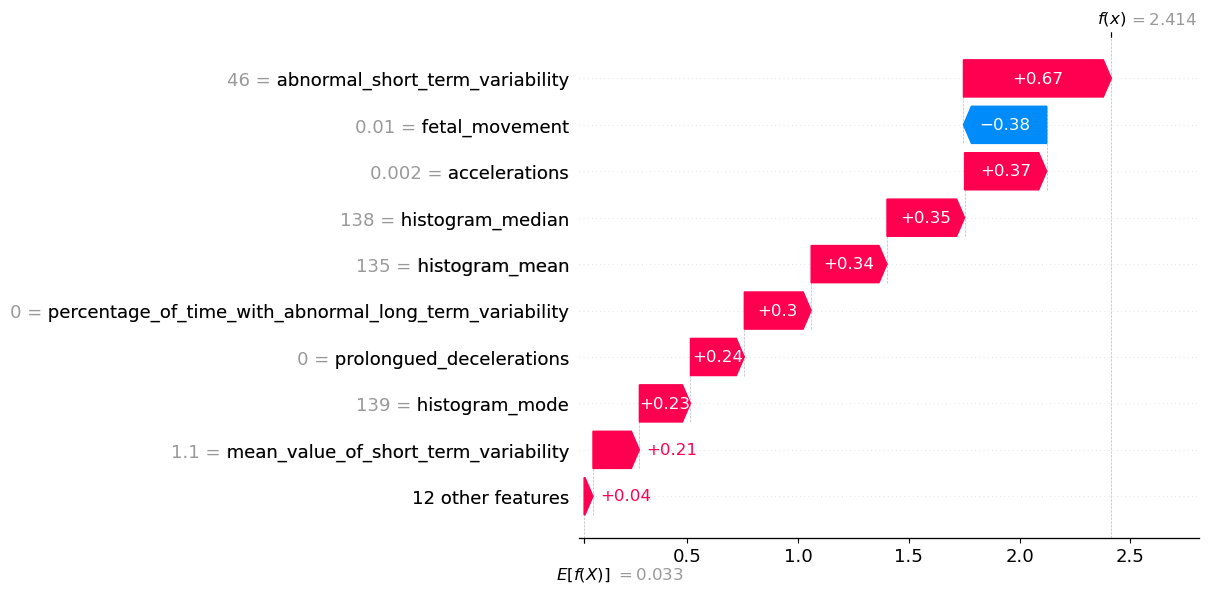

In [20]:
shap.plots.waterfall(shap_values[0, :, pred])

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

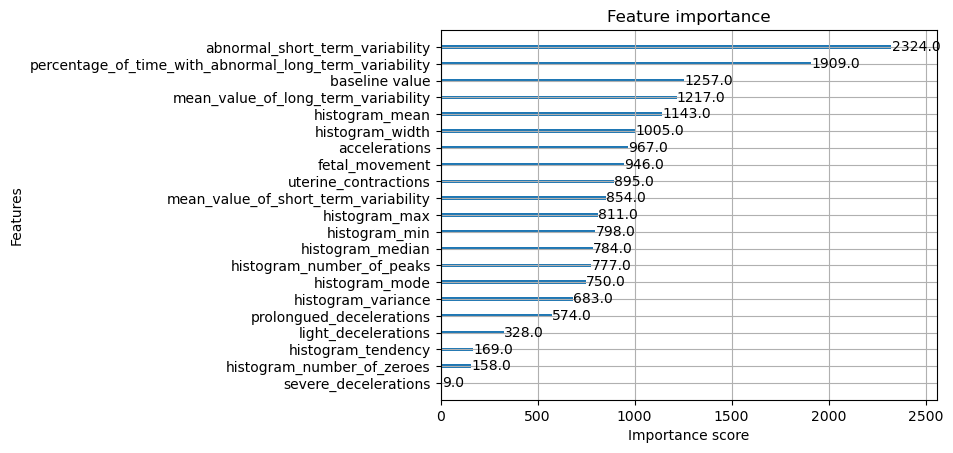

In [16]:
import xgboost as xgb
xgb.plot_importance(model)